In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import berserk
import os
from scipy.stats import chi2_contingency
from dotenv import load_dotenv

# Load data
df = pd.read_csv('data/games.csv')
df.dropna(subset=['white_rating', 'black_rating', 'opening_name', 'winner'], inplace=True)

# Feature Engineering: Rating Brackets
bins = [0, 1200, 1800, 3000]
labels = ['Beginner', 'Intermediate', 'Advanced']
df['rating_bracket'] = pd.cut(df['white_rating'], bins=bins, labels=labels)

print(f"Dataset loaded with {len(df)} records.")   

Dataset loaded with 20058 records.


# Focus on Top 10 most frequent openings
top_10_openings = df['opening_name'].value_counts().nlargest(10).index
df_top_10 = df[df['opening_name'].isin(top_10_openings)]

# Chi-Square Test
contingency_table = pd.crosstab(df_top_10['opening_name'], df_top_10['rating_bracket'])
chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"P-value: {p:.4e}")

if p < 0.05:
    print("Result: Reject the Null Hypothesis. Opening choice depends on player skill level.")
else:
    print("Result: Fail to Reject the Null Hypothesis.")

In [49]:
# Focus on Top 10 most frequent openings
top_10_openings = df['opening_name'].value_counts().nlargest(10).index
df_top_10 = df[df['opening_name'].isin(top_10_openings)]

# Chi-Square Test
contingency_table = pd.crosstab(df_top_10['opening_name'], df_top_10['rating_bracket'])
chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"P-value: {p:.4e}")

if p < 0.05:
    print("Result: Reject the Null Hypothesis. Opening choice depends on player skill level.")
else:
    print("Result: Fail to Reject the Null Hypothesis.")

Chi-Square Statistic: 248.3951
P-value: 1.7287e-42
Result: Reject the Null Hypothesis. Opening choice depends on player skill level.


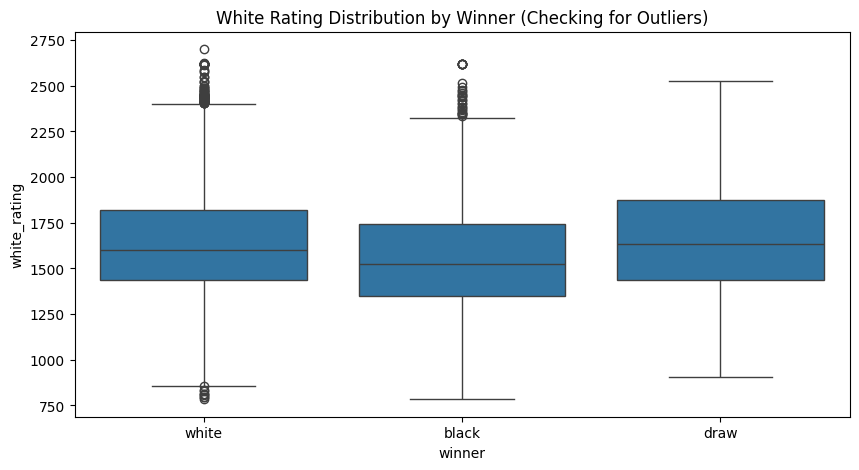

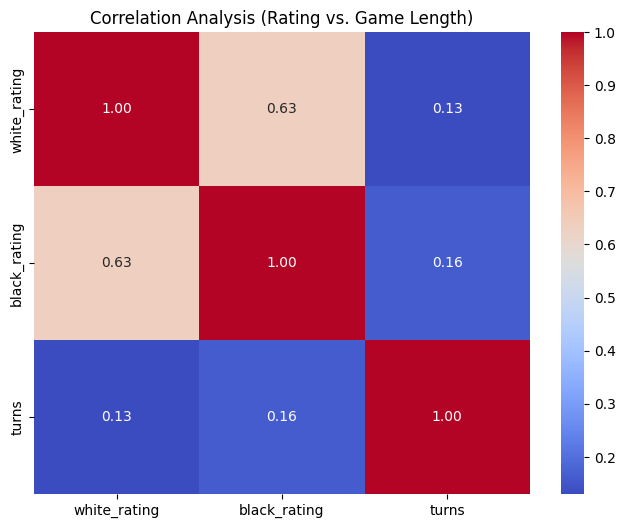

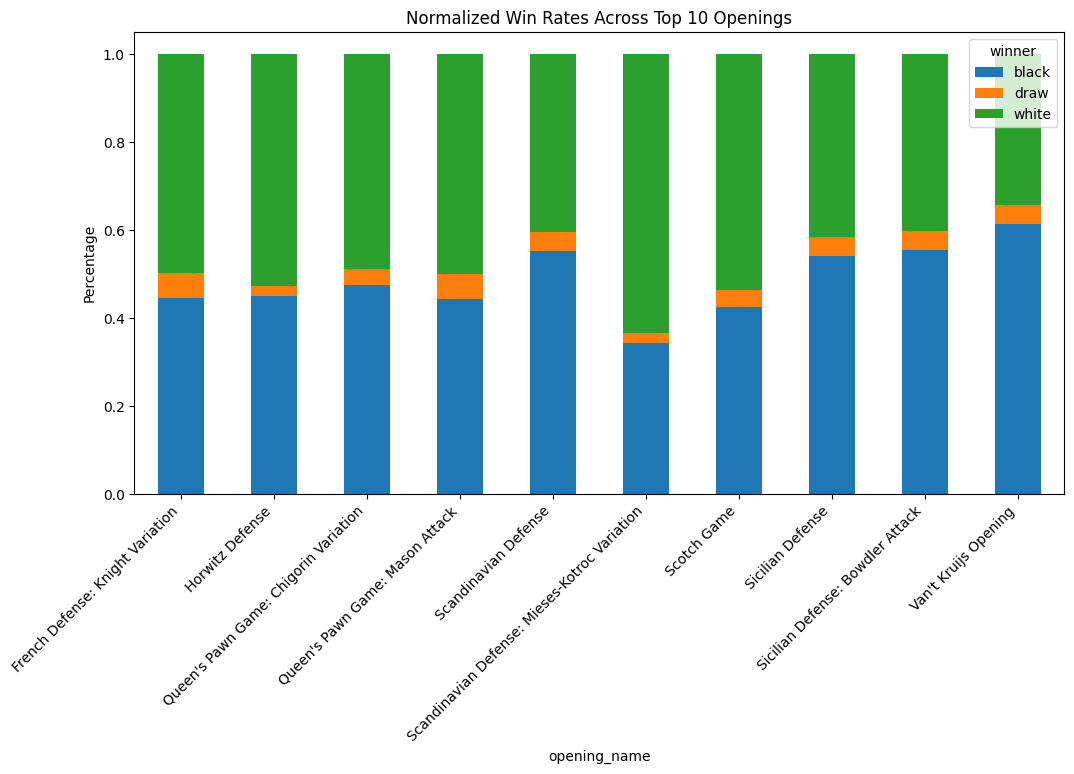

In [50]:
# 1. Distribution of Ratings by Winner (Outlier Detection)
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='winner', y='white_rating')
plt.title('White Rating Distribution by Winner (Checking for Outliers)')
plt.show()

# 2. Correlation Heatmap
# Selecting numerical columns for correlation
plt.figure(figsize=(8, 6))
correlation_matrix = df[['white_rating', 'black_rating', 'turns']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Analysis (Rating vs. Game Length)')
plt.show()

# 3. Win Rate per Opening (Factor Analysis)
win_rates = df_top_10.groupby('opening_name')['winner'].value_counts(normalize=True).unstack()
win_rates.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('Normalized Win Rates Across Top 10 Openings')
plt.ylabel('Percentage')
plt.xticks(rotation=45, ha='right')
plt.show()

In [51]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Select features and target
ml_df = df[['white_rating', 'black_rating', 'opening_name', 'rating_bracket', 'winner']].copy()

# 2. Encode categorical variables
le_opening = LabelEncoder()
le_bracket = LabelEncoder()
le_winner = LabelEncoder()

ml_df['opening_name'] = le_opening.fit_transform(ml_df['opening_name'])
ml_df['rating_bracket'] = le_bracket.fit_transform(ml_df['rating_bracket'].astype(str))
y = le_winner.fit_transform(ml_df['winner']) # Target variable

X = ml_df.drop('winner', axis=1)

# 3. Split into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data successfully split and encoded.")

Data successfully split and encoded.


--- Machine Learning Model Evaluation ---
Accuracy Score: 0.6269

Classification Report:
              precision    recall  f1-score   support

       black       0.62      0.62      0.62      1816
        draw       0.38      0.09      0.14       192
       white       0.64      0.69      0.66      2004

    accuracy                           0.63      4012
   macro avg       0.55      0.46      0.47      4012
weighted avg       0.62      0.63      0.62      4012



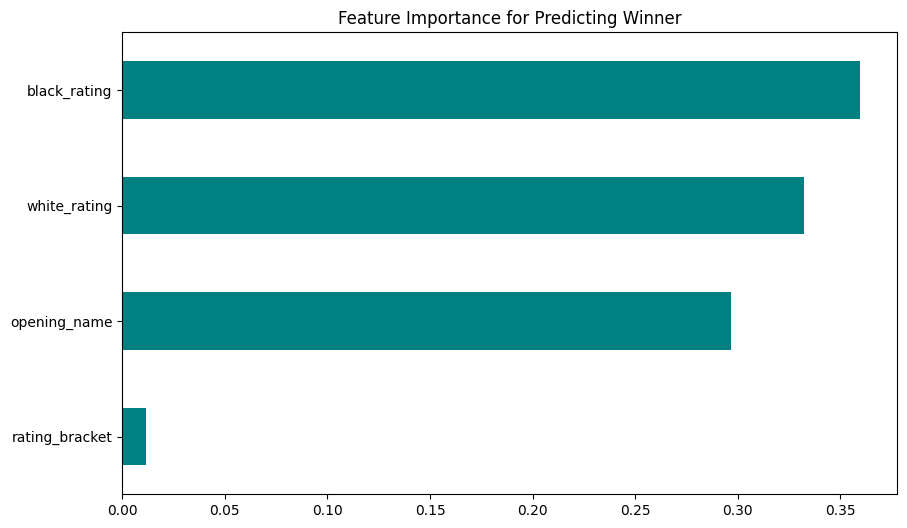

In [52]:
# 1. Initialize the Model (Random Forest)
# We use Random Forest as it handles both numerical and categorical features well.
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Train the model
rf_model.fit(X_train, y_train)

# 3. Make Predictions
y_pred = rf_model.predict(X_test)

# 4. Evaluation Results
print("--- Machine Learning Model Evaluation ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le_winner.classes_))

# 5. Feature Importance - Which factor matters most?
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
plt.figure(figsize=(10, 6))
importances.sort_values().plot(kind='barh', color='teal')
plt.title('Feature Importance for Predicting Winner')
plt.show()

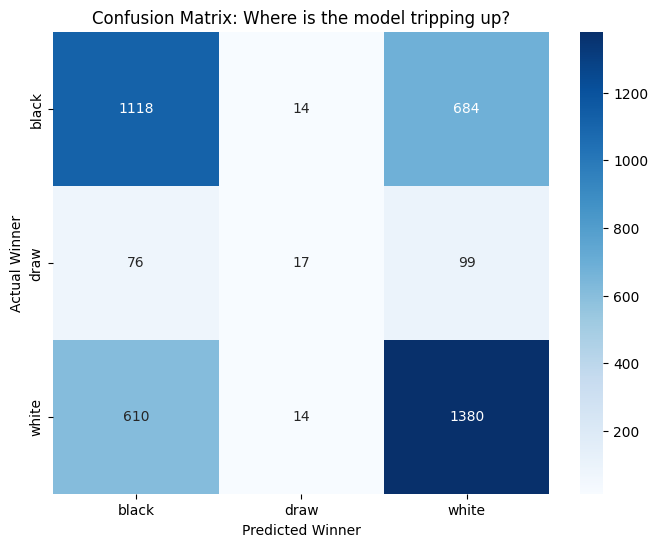

In [53]:
# Create a Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le_winner.classes_, 
            yticklabels=le_winner.classes_)
plt.xlabel('Predicted Winner')
plt.ylabel('Actual Winner')
plt.title('Confusion Matrix: Where is the model tripping up?')
plt.show()

In [54]:
def predict_matchup(white_rating, black_rating, opening_name):
    # 1. Prepare input with the exact column names used during training
    opening_encoded = le_opening.transform([opening_name])[0]
    
    if white_rating <= 1200: bracket = 'Beginner'
    elif white_rating <= 1800: bracket = 'Intermediate'
    else: bracket = 'Advanced'
    bracket_encoded = le_bracket.transform([bracket])[0]
    
    # Create a DataFrame so sklearn is happy
    input_df = pd.DataFrame([[white_rating, black_rating, opening_encoded, bracket_encoded]], 
                            columns=['white_rating', 'black_rating', 'opening_name', 'rating_bracket'])
    
    # 2. Predict
    prediction = rf_model.predict(input_df)
    winner = le_winner.inverse_transform(prediction)[0]
    probs = rf_model.predict_proba(input_df)[0]
    
    print(f"--- Matchup Analysis ---")
    print(f"White ({white_rating}) vs Black ({black_rating}) playing {opening_name}")
    print(f"Predicted Winner: {winner.upper()}")
    print(f"Confidence: {max(probs)*100:.2f}%")

# Test again - the blue warnings should be gone!
predict_matchup(white_rating=1500, black_rating=1400, opening_name='Sicilian Defense')

--- Matchup Analysis ---
White (1500) vs Black (1400) playing Sicilian Defense
Predicted Winner: BLACK
Confidence: 60.00%
